In [ ]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import matplotlib.gridspec as gridspec
from scipy import stats as scipy_stats

sys.path.append(str(Path("../PROF/data_analysis").resolve()))

from build_panel import load_panel_acc, load_panel_prof
from plot_style_utils import apply_plot_theme, style_axis, PALETTE

In [2]:
#=======================================
# LOAD DATA
#=======================================

panel_acc = load_panel_acc()
panel_prof = load_panel_prof()

panel = pd.merge(
    panel_acc,
    panel_prof[["Ticker", "Year", "REVT"]],
    on=["Ticker", "Year"],
    how="left"
)

panel = panel.sort_values(["Ticker", "Year"])

print(f"Panel loaded: {len(panel):,} firm-years")
print(f"Firms: {panel["Ticker"].nunique()}")

Panel loaded: 9,866 firm-years
Firms: 641


In [3]:
#=======================================
# WORKING CAPITAL ACCRUALS
#=======================================

grp = panel.groupby("Ticker", sort=False)

delta_ca = grp["ACT"].diff()
delta_cash = grp["CHE"].diff()
delta_cl = grp["LCT"].diff()
delta_std = grp["STD"].diff()
delta_tp = grp["TXP"].diff()

panel["WCAcc_raw"] = (
    (delta_ca - delta_cash)
    - (delta_cl - delta_std - delta_tp)
)

panel["at_lag"] = grp["AT"].shift(1)

panel["WCAcc"] = (
    panel["WCAcc_raw"] / panel["at_lag"].replace(0, np.nan)
)

In [4]:
#=======================================
# REGRESSION VARIABLES
#=======================================

at_lag = panel["at_lag"].replace(0, np.nan)

panel["CFO_t"] = panel["OANCF"] / at_lag
panel["CFO_tm1"] = grp["CFO_t"].shift(1)
panel["CFO_tm1_scaled"] = grp["OANCF"].shift(1) / at_lag

panel["delta_revt"] = grp["REVT"].diff() / at_lag

panel["PPEGT_scaled"] = panel["PPEGT"] / at_lag

REGRESSORS = ["CFO_tm1_scaled", "CFO_t", "delta_revt", "PPEGT_scaled"]
DEPENDENT = "WCAcc"

In [5]:
#=======================================
# CROSS-SECTIONAL OLS BY YEAR
#=======================================

residuals = pd.Series(np.nan, index=panel.index)
year_results = []

MIN_FIRMS_PER_YEAR = 20

for year, group in panel.groupby(panel["Year"]):

    reg_cols = [DEPENDENT] + REGRESSORS
    sub = group[reg_cols].dropna()

    if len(sub) < MIN_FIRMS_PER_YEAR:
        year_results.append({
            'year': year, 'n': len(sub),
            'r2': np.nan, 'status': 'SKIP (too few obs)'
        })
        continue

    y = sub[DEPENDENT].values
    X = sub[REGRESSORS].values

    # OLS via numpy for speed
    X_aug = np.column_stack([np.ones(len(X)), X])
    try:
        b, _, _, _ = np.linalg.lstsq(X_aug, y, rcond=None)
    except np.linalg.LinAlgError:
        year_results.append({
            'year': year, 'n': len(sub),
            'r2': np.nan, 'status': 'ERROR'
        })
        continue
    
    fitted = X_aug @ b
    resid  = y - fitted

    # R-squared
    ss_res = np.sum(resid ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2     = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # Store residuals aligned to original panel index
    residuals.loc[sub.index] = resid

    year_results.append({
        'year': year, 'n': len(sub), 'r2': r2,
        'alpha': b[0],
        'b_cfo_lag': b[1], 'b_cfo_cur': b[2],
        'b_drev': b[3],    'b_ppe': b[4],
        'status': 'OK'
    })


panel['dd_residual'] = residuals

yr_df = pd.DataFrame(year_results).set_index('year')
n_ok  = (yr_df['status'] == 'OK').sum()
print(f'Regressions run: {n_ok} / {len(yr_df)} years succeeded')
print(f'Residuals: {panel["dd_residual"].notna().sum():,} non-null')


Regressions run: 19 / 20 years succeeded
Residuals: 3,548 non-null


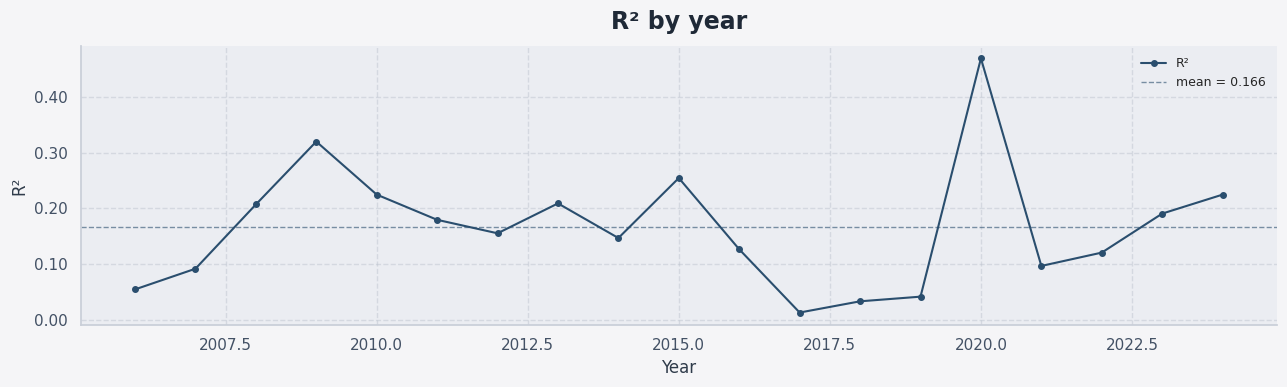

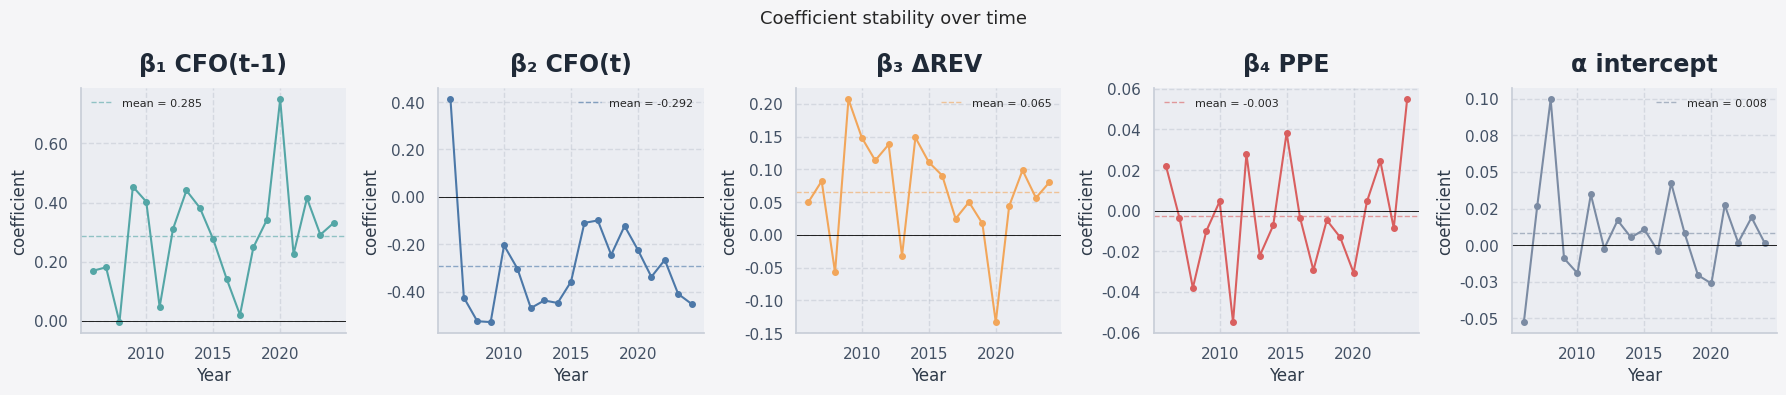


Average R²: 0.166
        n     r2  alpha  b_cfo_lag  b_cfo_cur  b_drev  b_ppe
year                                                        
2006   37  0.055 -0.053      0.169      0.411   0.050  0.022
2007   50  0.092  0.027      0.181     -0.425   0.082 -0.004
2008   62  0.207  0.100     -0.004     -0.525  -0.057 -0.038
2009   62  0.320 -0.009      0.454     -0.529   0.207 -0.010
2010   72  0.225 -0.019      0.403     -0.205   0.148  0.005
2011   89  0.180  0.035      0.047     -0.303   0.114 -0.055
2012  116  0.155 -0.002      0.311     -0.470   0.138  0.028
2013  146  0.209  0.017      0.441     -0.437  -0.032 -0.022
2014  169  0.147  0.005      0.382     -0.448   0.149 -0.007
2015  173  0.255  0.011      0.276     -0.358   0.111  0.038
2016  187  0.127 -0.004      0.142     -0.110   0.091 -0.003
2017  210  0.013  0.042      0.020     -0.100   0.025 -0.029
2018  223  0.033  0.008      0.249     -0.245   0.050 -0.005
2019  241  0.042 -0.021      0.341     -0.123   0.017 -0.013
2020 

In [8]:
#=======================================
# PLOT DIAGNOSTICS
#=======================================

apply_plot_theme()

yr_ok = yr_df[yr_df["status"] == "OK"]
fmt_decimal = plt.FuncFormatter(lambda x, _: f"{x:.2f}")

COEF_DEFS = [
    ("b_cfo_lag", "β₁ CFO(t-1)", PALETTE["teal"]),
    ("b_cfo_cur", "β₂ CFO(t)",   PALETTE["blue"]),
    ("b_drev",    "β₃ ΔREV",     PALETTE["orange"]),
    ("b_ppe",     "β₄ PPE",      PALETTE["red"]),
    ("alpha",     "α intercept", PALETTE["slate"]),
]

# ── Figure 1: R² ──────────────────────────────────────────────────────────────
fig1, ax = plt.subplots(figsize=(13, 4))
ax.plot(yr_ok.index, yr_ok["r2"], "o-", color=PALETTE["navy"], lw=1.5, ms=4, label="R²")
ax.axhline(yr_ok["r2"].mean(), color=PALETTE["navy"], lw=1, ls="--", alpha=0.6,
           label=f"mean = {yr_ok['r2'].mean():.3f}")
style_axis(ax, title="R² by year", xlabel="Year", ylabel="R²")
ax.yaxis.set_major_formatter(fmt_decimal)
ax.legend(fontsize=9)
fig1.tight_layout()
plt.show()

# ── Figure 2: coefficients ────────────────────────────────────────────────────
fig2, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
fig2.suptitle("Coefficient stability over time", fontsize=13)

for ax, (col, lbl, clr) in zip(axes, COEF_DEFS):
    ax.plot(yr_ok.index, yr_ok[col], "o-", color=clr, lw=1.5, ms=4)
    ax.axhline(yr_ok[col].mean(), color=clr, lw=1, ls="--", alpha=0.6,
               label=f"mean = {yr_ok[col].mean():.3f}")
    ax.axhline(0, color="black", lw=0.6)
    style_axis(ax, title=lbl, xlabel="Year", ylabel="coefficient")
    ax.yaxis.set_major_formatter(fmt_decimal)
    ax.legend(fontsize=8)

fig2.tight_layout()
plt.show()

print(f"\nAverage R²: {yr_ok['r2'].mean():.3f}")
print(yr_ok[["n", "r2", "alpha", "b_cfo_lag", "b_cfo_cur", "b_drev", "b_ppe"]].round(3).to_string())

In [9]:
SIGMA2_FLOOR = 1e-4    # prevents zero variance
SIGMA2_WINSOR = 0.99   # cap at 99th percentile

def rolling_residual_std(df: pd.DataFrame,
                          firm_col: str,
                          year_col: str,
                          resid_col: str,
                          window: int,
                          min_periods: int = 2) -> pd.Series:
    """
    For each firm-year, compute std of residuals over the
    trailing `window` years (EXCLUDING the current year).

    Implementation: shift residuals forward by 1, then rolling std.
    This ensures year t uses only t-1, t-2, ... t-window.
    """
    # Shift residuals by 1 within firm so current year is not included
    shifted = (
        df.groupby(firm_col, sort=False)[resid_col]
          .shift(1)
    )
    # Temporarily attach to df for grouped rolling
    tmp = df[[firm_col, year_col]].copy()
    tmp['_shifted'] = shifted

    roll_std = (
        tmp.groupby(firm_col, sort=False)['_shifted']
           .transform(lambda x:
               x.rolling(window=window, min_periods=min_periods).std()
           )
    )
    return roll_std


# ── Compute for both windows ──────────────────────────────────────────────────
panel['dd_sigma_3yr'] = rolling_residual_std(
    panel, "Ticker", "Year", 'dd_residual', window=3
)
panel['dd_sigma_5yr'] = rolling_residual_std(
    panel, "Ticker", "Year", 'dd_residual', window=5
)

for col in ['dd_sigma_3yr', 'dd_sigma_5yr']:
    n = panel[col].notna().sum()
    print(f'{col}: {n:,} non-null ({n/len(panel)*100:.1f}%)')

dd_sigma_3yr: 2,750 non-null (27.9%)
dd_sigma_5yr: 3,025 non-null (30.7%)


In [10]:
def clean_sigma(s: pd.Series, label: str) -> pd.Series:
    """Floor, winsorise, fill NaN with cross-sectional median."""
    s = s.copy()

    # Fill NaN (firms without enough history) with cross-sectional median
    n_missing = s.isna().sum()
    if n_missing:
        med = s.median()
        s   = s.fillna(med)
        print(f'  [{label}] Filled {n_missing:,} NaN with median ({med:.4f})')

    # Floor
    s = s.clip(lower=SIGMA2_FLOOR)

    # Winsorise upper tail
    cap = s.quantile(SIGMA2_WINSOR)
    n_capped = (s > cap).sum()
    if n_capped:
        print(f'  [{label}] Capped {n_capped:,} values at 99th pct ({cap:.4f})')
    s = s.clip(upper=cap)
    return s


panel['dd_sigma_3yr'] = clean_sigma(panel['dd_sigma_3yr'], '3yr')
panel['dd_sigma_5yr'] = clean_sigma(panel['dd_sigma_5yr'], '5yr')

print('\nSigma summary statistics:')
display(panel[['dd_sigma_3yr', 'dd_sigma_5yr']].describe().round(4))

  [3yr] Filled 7,116 NaN with median (0.0392)
  [3yr] Capped 99 values at 99th pct (0.2238)
  [5yr] Filled 6,841 NaN with median (0.0436)
  [5yr] Capped 99 values at 99th pct (0.2452)

Sigma summary statistics:


,dd_sigma_3yr,dd_sigma_5yr
count,9866.0000,9866.0000
mean,0.0444,0.0493
std,0.0294,0.0322
min,0.0001,0.0001
25%,0.0392,0.0436
50%,0.0392,0.0436
75%,0.0392,0.0436
max,0.2238,0.2452
